![image info](https://user-images.githubusercontent.com/91945811/146929832-e78ff1f4-2739-41b1-acd3-019a39b6a42c.png)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel("produktion.xlsx")

# Die ersten Zeilen des Datensatzes anzeigen
df.head()

,ProduktionsID,Startzeitpunkt,Endzeitpunkt,Gesamt_Einheiten,Fehlerhafte_Einheiten
0,1,2024-01-01 00:00:00,2024-01-01 08:00:00,448,31.0
1,2,2024-01-01 01:00:00,2024-01-01 06:00:00,939,9.0
2,3,2024-01-01 02:00:00,2024-01-01 11:00:00,878,15.0
3,4,2024-01-01 03:00:00,2024-01-01 09:00:00,972,6.0
4,5,2024-01-01 04:00:00,2024-01-01 12:00:00,328,16.0


### **Hintergrund der Daten**
Der vorliegende Datensatz beschreibt Produktionsprozesse in einer Fertigungsanlage. Jeder Eintrag steht für einen Produktionslauf mit einer eindeutigen **ProduktionsID**. Zu jedem Produktionslauf sind folgende Daten erfasst:

- **Startzeitpunkt & Endzeitpunkt**: Der Zeitraum, in dem der Produktionsprozess stattgefunden hat.
- **Gesamt_Einheiten**: Die Gesamtzahl der hergestellten Einheiten während des Produktionslaufs.
- **Fehlerhafte_Einheiten**: Die Anzahl der fehlerhaften Einheiten, die während des Produktionslaufs produziert wurden.

Diese Daten sind für die Berechnung wichtiger **operative KPIs (Key Performance Indicators)** in der Produktion geeignet.

---

### **Aufgabensammlung für operative KPIs**

#### **1. Durchlaufzeit berechnen**
   - Berechne die Durchlaufzeit jedes Produktionslaufs in Stunden.
   - Bestimme die durchschnittliche Durchlaufzeit aller Produktionsläufe.

In [4]:
# 1. Durchlaufzeit berechnen (in Stunden)
df["Durchlaufzeit"] = (df["Endzeitpunkt"] - df["Startzeitpunkt"]).dt.total_seconds() / 3600

In [5]:
df["Durchlaufzeit"].mean()

5.906

#### **2. Fehlerquote analysieren**
   - Berechne die Fehlerquote für jeden Produktionslauf.
   - Bestimme die Produktionsläufe mit der höchsten und niedrigsten Fehlerquote. Verwende hierzu `idxmax()` und `idxmin()`

In [7]:
# 2. Fehlerquote berechnen
df["Fehlerquote"] = (df["Fehlerhafte_Einheiten"] / df["Gesamt_Einheiten"]) * 100

In [8]:
# Produktionslauf mit der höchsten Fehlerquote
max_fehlerrate = df.loc[df["Fehlerquote"].idxmax()]

# Produktionslauf mit der niedrigsten Fehlerquote
min_fehlerrate = df.loc[df["Fehlerquote"].idxmin()]

# Ergebnisse als DataFrame anzeigen
fehlerrate_extreme = pd.DataFrame([max_fehlerrate, min_fehlerrate])

display(fehlerrate_extreme)

,ProduktionsID,Startzeitpunkt,Endzeitpunkt,Gesamt_Einheiten,Fehlerhafte_Einheiten,Durchlaufzeit,Fehlerquote
469,470,2024-01-20 13:00:00,2024-01-20 21:00:00,143,80.713295,8.0,56.442864
82,83,2024-01-04 10:00:00,2024-01-04 12:00:00,114,0.000000,2.0,0.000000


#### **3. Produktionsrate bestimmen**
   - Berechne die Produktionsrate (Einheiten pro Stunde) für jeden Produktionslauf.
   - Visualisiere die Produktionsrate über die Zeit als Liniendiagramm.

In [10]:
# 3. Produktionsrate berechnen (Einheiten pro Stunde)
df["Produktionsrate"] = df["Gesamt_Einheiten"] / df["Durchlaufzeit"]


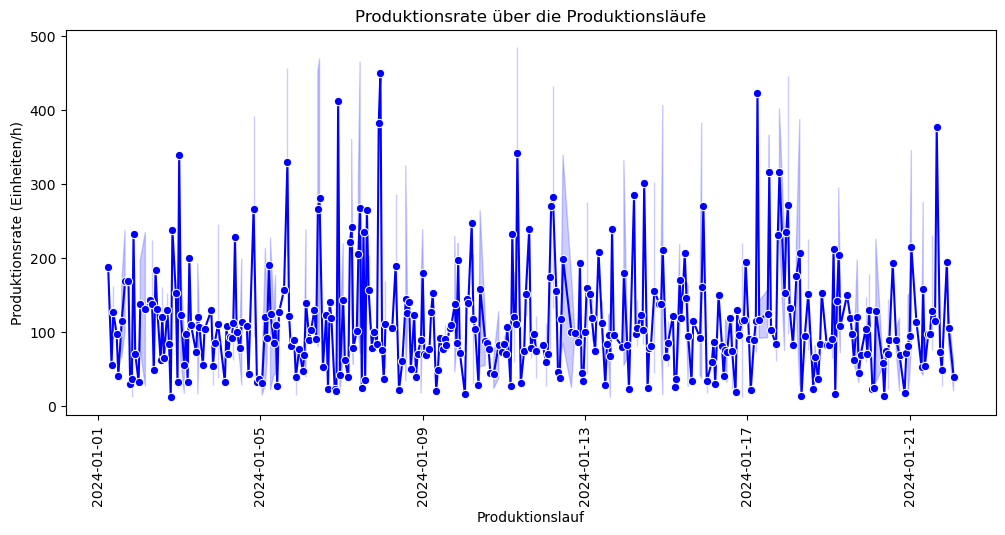

In [11]:
# Produktionsrate über die Zeit
plt.figure(figsize=(12, 5))
sns.lineplot(x=df["Endzeitpunkt"], y=df["Produktionsrate"], marker="o", color="b")
plt.xlabel("Produktionslauf")
plt.ylabel("Produktionsrate (Einheiten/h)")
plt.title("Produktionsrate über die Produktionsläufe")
plt.xticks(rotation=90)
plt.show()

#### **4. Kumulative Produktion und Fehlerzahl analysieren**
   - Erstelle eine kumulierte Summe der produzierten und fehlerhaften Einheiten über die Zeit.
   - Visualisiere die kumulierte Produktion und Fehlerzahl als Diagramm.

In [13]:

# 4. Kumulative Summen für produzierte und fehlerhafte Einheiten
df["Kumulative_Gesamt_Einheiten"] = df["Gesamt_Einheiten"].cumsum()
df["Kumulative_Fehlerhafte_Einheiten"] = df["Fehlerhafte_Einheiten"].cumsum()


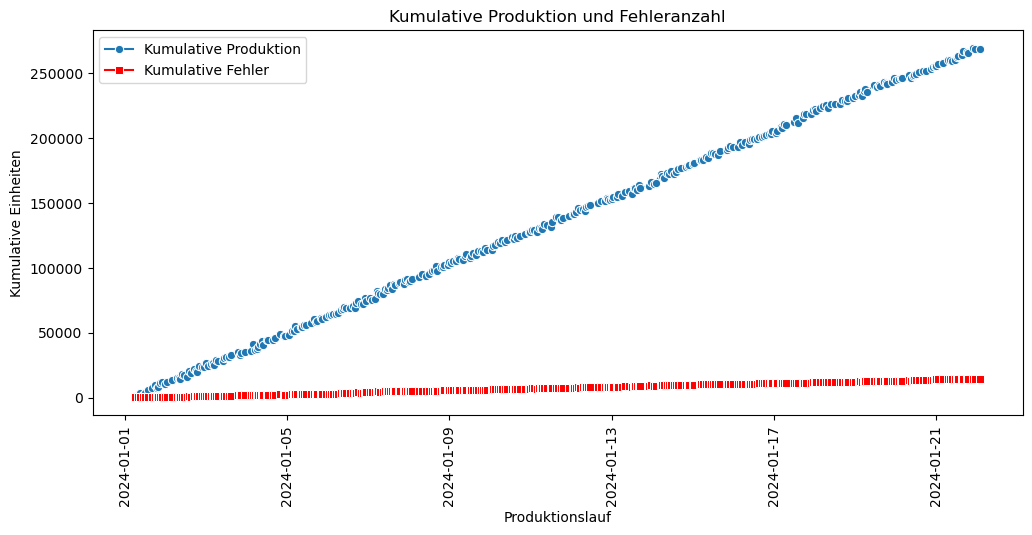

In [14]:
plt.figure(figsize=(12, 5))
sns.lineplot(x=df["Endzeitpunkt"], y=df["Kumulative_Gesamt_Einheiten"], label="Kumulative Produktion", marker="o")
sns.lineplot(x=df["Endzeitpunkt"], y=df["Kumulative_Fehlerhafte_Einheiten"], label="Kumulative Fehler", marker="s", color="r")
plt.xlabel("Produktionslauf")
plt.ylabel("Kumulative Einheiten")
plt.title("Kumulative Produktion und Fehleranzahl")
plt.legend()
plt.xticks(rotation=90)
plt.show()

#### **5. Zeitliche Entwicklung der Qualität untersuchen**
   - Untersuche, ob es Tageszeiten gibt, in denen mehr fehlerhafte Einheiten produziert werden.


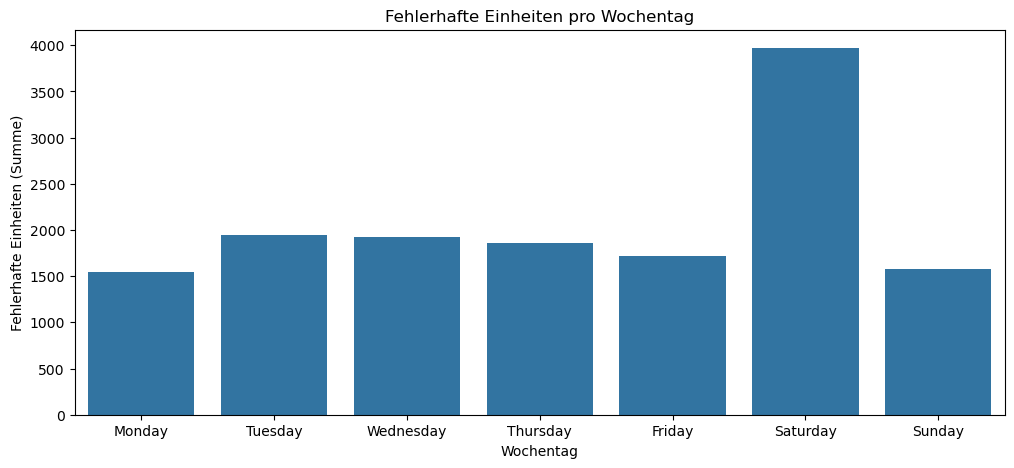

In [16]:
# Extrahiere den Wochentag aus dem Startzeitpunkt
df["Wochentag"] = df["Startzeitpunkt"].dt.day_name()

# Aggregiere die Fehlerhaften Einheiten nach Wochentag
fehler_nach_tag = df.groupby("Wochentag")["Fehlerhafte_Einheiten"].sum()

# Wochentage in der richtigen Reihenfolge sortieren
wochentag_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
fehler_nach_tag = fehler_nach_tag.reindex(wochentag_order)

# Visualisierung: Fehlerhafte Einheiten nach Wochentag
plt.figure(figsize=(12, 5))
sns.barplot(x=fehler_nach_tag.index, y=fehler_nach_tag.values)
plt.xlabel("Wochentag")
plt.ylabel("Fehlerhafte Einheiten (Summe)")
plt.title("Fehlerhafte Einheiten pro Wochentag")
plt.show()